In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
ATAC_path = Path('data') / 'ImmGenATAC18_AllOCRsInfo.csv'
ATAC_data = pd.read_csv(ATAC_path)
ATAC_data #head: zeigt nur erste 5 Zeilen --> trotzdem alles geladen

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_1,chr1,3020786,0.00,0.56,NaN,NaN,NaN,0.41,0.71,...,0.10,0.10,3.19,1.37,0.52,1.27,0.10,0.57,3.27,1.41
1,ImmGenATAC1219.peak_2,chr1,3087226,0.00,0.50,NaN,NaN,NaN,0.41,1.64,...,1.70,0.10,1.41,0.47,0.11,0.92,0.98,2.16,2.34,0.94
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512590,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
512591,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64
512592,ImmGenATAC1219.peak_512593,chrY,90813175,0.00,0.69,NaN,NaN,Erdr1,0.41,0.71,...,0.44,1.38,1.20,1.37,1.82,1.61,1.29,0.14,1.23,0.50
512593,ImmGenATAC1219.peak_512594,chrY,90813624,0.00,0.60,NaN,NaN,Erdr1,0.41,1.64,...,0.77,0.97,0.11,1.39,1.39,0.50,0.10,0.14,1.05,0.11


### <h1>ATAC_seq: Data Cleanup</h1>

<h2>Removing or imputing missing values</h2>

In [52]:
#number of rows
ATAC_data.__len__() 

512595

In [53]:
#number of missing data points per column
missing_values_count = ATAC_data.isnull().sum()
missing_values_count[missing_values_count > 0] #just show columes where data is missing

Included.in.systematic.analysis    177716
TSS                                498303
genes.within.100Kb                  84885
dtype: int64

**Data is missing in 3 columes**: Included.in.systematic.analysis, TSS, genes.within.100Kb  

**included in systematic analysis**: Boolean / yes-no flag indicating whether the authors considered this OCR reliable enough for downstream analyses in the paper
--> NaN: Yoshida et al. do not considerd it reliabale enough for further analysis and did't includ it in further analysis 

**TSS**: name of closest TSS gene
--> NaN: there isn't any TSS gene close to the peak

**genes within 100kb**: just lists all the genes in that range as str
--> NaN: If the peaks are not near any genes within 100 kb

In [54]:
# Wie viel prozent der cells sind missing values
total_cells = np.prod(ATAC_data.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing/total_cells) * 100
percent_missing

np.float64(1.5147097670894654)

In [55]:
#values of TSS that are not NaN
just_TSS = ATAC_data.loc[~ATAC_data ["TSS"].isnull(), "TSS"]
just_TSS

20           Xkr4
139        Mrpl15
145        Lypla1
157         Tcea1
159         Tcea1
           ...   
512467      Vamp7
512477      Tmlhe
512506    Eif2s3y
512522        Uty
512532      Ddx3y
Name: TSS, Length: 14292, dtype: str

In [56]:
#Wie viele prozent cells missing in TSS (enhancer)
TSS_total_missing = ATAC_data ["TSS"]. isnull().sum()
TSS_total_cells = len(ATAC_data)
print(ATAC_data ["TSS"]. notnull().sum())

percent_missing_TSS = (TSS_total_missing/TSS_total_cells) * 100
print(percent_missing_TSS)

14292
97.21183390395926


es fehlen **97%** der werte in TSS --> weil diese nicht in der Nähe einer TSS sind --> distal enahncers

In [57]:
#values of Included.in.systematic.analysis	 that are not NaN
ATAC_data["Included.in.systematic.analysis"].notnull().sum()

just_Incl_sa = ATAC_data.loc[ATAC_data["Included.in.systematic.analysis"].notnull(),"Included.in.systematic.analysis"]
just_Incl_sa

2         1.0
3         1.0
5         1.0
6         1.0
7         1.0
         ... 
512587    1.0
512588    1.0
512589    1.0
512590    1.0
512591    1.0
Name: Included.in.systematic.analysis, Length: 334879, dtype: float64

**Rauswerfen Daten nicht reliabel Sysematic analysis of paper**
--> also included in systematic analysis = NaN

<h3>P-value filtering

In [58]:
Minimum_pvalues = ATAC_data["_-log10_bestPvalue"].min()
ATAC_data.sort_values(by=["_-log10_bestPvalue"])

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
64295,ImmGenATAC1219.peak_64296,chr10,122421608,0.00,0.00,NaN,NaN,Avpr1a,0.41,0.10,...,0.10,0.10,0.11,0.11,0.11,0.11,0.34,0.11,0.11,0.11
508409,ImmGenATAC1219.peak_508410,chrX,106733598,0.00,0.00,NaN,NaN,NaN,0.41,0.10,...,0.10,0.29,0.11,0.47,0.52,0.14,0.10,0.11,0.51,0.11
506621,ImmGenATAC1219.peak_506622,chrX,80992224,0.67,0.22,NaN,NaN,Tmem47,0.41,0.10,...,0.44,0.36,0.11,0.11,0.11,0.53,0.10,2.16,1.61,0.11
501817,ImmGenATAC1219.peak_501818,chrUn_GL456390,17745,0.00,0.23,NaN,NaN,NaN,0.41,0.10,...,0.10,0.10,0.71,0.11,0.11,0.14,0.26,0.53,0.51,0.11
450165,ImmGenATAC1219.peak_450166,chr8,3343174,0.00,0.23,NaN,NaN,"Insr,A430078G23Rik,Arhgef18",0.41,0.10,...,0.10,0.10,0.11,0.11,0.11,0.11,0.10,0.11,0.64,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212977,ImmGenATAC1219.peak_212978,chr17,34000401,0.25,inf,1.0,H2-K1,"Platr17,BC051226,Daxx,Zbtb22,Tapbp,Rgl2,Pfdn6,...",57.63,52.34,...,104.36,106.10,79.63,115.50,103.96,66.25,98.69,98.72,66.62,110.97
501969,ImmGenATAC1219.peak_501970,chrUn_JH584304,55702,0.51,inf,1.0,NaN,Pisd-ps3,159.55,163.88,...,85.79,92.83,412.74,47.16,64.12,43.49,141.82,36.14,95.08,27.71
501973,ImmGenATAC1219.peak_501974,chrUn_JH584304,59065,0.00,inf,1.0,NaN,Pisd-ps3,90.52,145.41,...,253.14,174.38,321.14,225.03,225.22,108.31,225.58,108.38,282.02,256.03
501975,ImmGenATAC1219.peak_501976,chrUn_JH584304,59733,0.00,inf,1.0,Pisd-ps3,Pisd-ps3,727.42,727.42,...,727.42,727.42,727.42,727.42,727.42,727.42,727.42,727.42,727.42,727.42


In [59]:
logp_threshold_data = ATAC_data[ATAC_data["_-log10_bestPvalue"] < -np.log10(0.05)]
len(logp_threshold_data)

150265

**Teil von p value filtering: colume: _-log10_bestPvalue**

<br> untersuchen Datnesätze nach auffälligen niedrigen vs hohen p-values

wenn 0 dann heißt es p-value 1 --> Effekt wahrscheinlich rein zufällig zufällig (**entfernen?**)
wenn inf dann p-value fast 0 Sehr signifikant 

logp_threshold alle die kleiner sind als ein p von 0.05 --> signifikante Werte

inf als 0 ersetzen?

*TO BE CONTINUED*

In [60]:
not_Incl_sa = ATAC_data["Included.in.systematic.analysis"].isnull()
logp_threshold_data = ATAC_data["_-log10_bestPvalue"] < -np.log10(0.05)
ATAC_data[not_Incl_sa & logp_threshold_data]

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_1,chr1,3020786,0.00,0.56,NaN,NaN,NaN,0.41,0.71,...,0.10,0.10,3.19,1.37,0.52,1.27,0.10,0.57,3.27,1.41
1,ImmGenATAC1219.peak_2,chr1,3087226,0.00,0.50,NaN,NaN,NaN,0.41,1.64,...,1.70,0.10,1.41,0.47,0.11,0.92,0.98,2.16,2.34,0.94
10,ImmGenATAC1219.peak_11,chr1,3445768,0.00,0.84,NaN,NaN,NaN,0.41,0.10,...,0.87,0.54,0.11,1.37,0.11,0.11,0.98,1.12,1.04,0.11
12,ImmGenATAC1219.peak_13,chr1,3505885,0.01,0.62,NaN,NaN,NaN,0.41,0.71,...,0.44,0.54,0.23,0.11,0.51,1.59,2.23,1.33,3.39,0.93
15,ImmGenATAC1219.peak_16,chr1,3535704,0.03,1.09,NaN,NaN,NaN,0.41,0.10,...,1.70,1.41,2.58,0.95,0.11,1.56,0.88,1.33,1.23,7.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512563,ImmGenATAC1219.peak_512564,chrY,90797463,0.00,0.65,NaN,NaN,Erdr1,2.36,0.10,...,1.60,1.83,0.66,1.39,2.19,0.50,0.75,0.90,1.04,0.11
512566,ImmGenATAC1219.peak_512567,chrY,90798663,0.00,0.91,NaN,NaN,Erdr1,0.41,2.57,...,2.23,1.79,0.23,0.47,3.63,2.82,1.75,1.73,1.64,1.03
512574,ImmGenATAC1219.peak_512575,chrY,90802747,0.00,1.21,NaN,NaN,Erdr1,0.41,0.10,...,1.93,0.36,0.59,2.24,2.90,1.61,1.91,3.83,1.64,2.97
512592,ImmGenATAC1219.peak_512593,chrY,90813175,0.00,0.69,NaN,NaN,Erdr1,0.41,0.71,...,0.44,1.38,1.20,1.37,1.82,1.61,1.29,0.14,1.23,0.50


<p style="color: pink;">Pre-Filtering in Yoshida </p>
included in systematic analysis Werte die NaN sind, haben yoshida et al. rausgenommen, weil die Ihnen zu unverlässig waren. <br>
Wir haben alle Werte gefiltert die ein größeren p value haben als 0.05, also für uns nicht verlässlich. Diese sind weniger als die Yoshida et al. nicht included haben, aber alle 150265 fallen darunter.

<h2>Blacklist Filtering

In [61]:
cols = [
    "gene_name",
    "transcript_name",
    "chrom",
    "strand",
    "txStart",
    "txEnd",
    "cdsStart",
    "cdsEnd",
    "exonCount",
    "exonStarts",
    "exonEnds"
]
ATAC_path_geanno = Path('data') / "Gene annotations.txt"

Gen_annotations = pd.read_csv(ATAC_path_geanno, sep="\t", names=cols)
# need to tell pandas that the txt is tab seperated
Gen_annotations.head()


,gene_name,transcript_name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds
0,Wdsub1,NM_001159636,chr2,-,59855193,59882606,59855270,59878527,11,"59855193,59858609,59861560,59862619,59862816,5...","59855275,59858750,59861737,59862726,59862857,5..."
1,Rbm18,NM_001159635,chr2,-,36116078,36136704,36117814,36134247,6,"36116078,36120812,36122851,36127214,36134134,3...","36117974,36120898,36122938,36127251,36134263,3..."
2,Prrc2b,NM_001159634,chr2,+,32151147,32234537,32182511,32230742,32,"32151147,32182457,32183122,32185344,32187480,3...","32151291,32182626,32183300,32185447,32187553,3..."
3,Ildr2,NM_001164528,chr1,+,166254138,166316832,166254375,166310795,10,"166254138,166269304,166270498,166291415,166294...","166254466,166269637,166270618,166291472,166294..."
4,Perm1,NM_172417,chr4,+,156215926,156221307,156217000,156220222,4,"156215926,156216716,156219740,156220109,","156215975,156219185,156219866,156221307,"


In [62]:
ATAC_path_blacklist = Path('data') / 'mm10.blacklist.bed'
ATAC_blacklist_data = pd.read_csv(ATAC_path_blacklist)
ATAC_blacklist_data.head()
ATAC_blacklist_data.__len__()

163

In [63]:
Gen_annotations[Gen_annotations["txStart"] == 59855193]
(Gen_annotations['txStart'] == 59855193).any #positiv Probe wird gefunden

<bound method Series.any of 0         True
1        False
2        False
3        False
4        False
         ...  
47377    False
47378    False
47379    False
47380    False
47381    False
Name: txStart, Length: 47382, dtype: bool>

In [64]:
Gen_annotations[Gen_annotations["txStart"] == 24541940]
#or
(Gen_annotations["txStart"] == 24541940).any() #Start von blacklisted Beispiel-gen ist nicht zu finden

np.False_

Wir haben die blacklisted Gene als Tabelle auslesen lassen und dann die Startnummern mit denen der annotierten Gene im Gene annotations Dataset verglichen. Die blacklisted Gene sind nicht im Gene annotations Dataset wiederzufinden, daher ist davon auszugehen, dass diese blacklisted Gene bereits zu Beginn des Data Cleanups von Yoshida et al. entfernt wurde.

<h2>ATAC_data_removed: Datensatz ohne  unreliable data

In [65]:
threshold = -np.log10(0.05)
ATAC_data_removed = ATAC_data[ATAC_data["_-log10_bestPvalue"] >= threshold].copy()
ATAC_data_removed.head()
ATAC_data_removed.__len__() 

362330

### <h2> Exploration of Data nach Tilmann

In [32]:
pd.set_option("display.max_rows", None)      
ATAC_data_removed.describe()
ATAC_data_removed.__len__()

/Users/rosavasila/topic04_team03/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


362330

count    # Anzahl der nicht-NaN Werte
mean     # Mittelwert ohne NaN
std      # Standardabweichung ohne NaN

**--> NaN doch lieber ersetzen?**

<h3> Creating a function for log-tranformation </h3>
log transformation besser, um Werte zu vergleichen

In [33]:
def log_transform(df):
    df_numeric_cols = df.select_dtypes(include=[np.number]).columns
    log_df = df.copy()
    log_df[df_numeric_cols] = np.log1p(log_df[df_numeric_cols])
    return log_df

<h3> Using the log_transform function on the filtered values and creating a histogram </h3>

In [35]:
log_ATAC = log_transform(ATAC_data_removed)
log_ATAC.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,14.953379,0.067659,2.468100,0.693147,NaN,NaN,1.211941,0.095310,...,0.625938,0.431782,1.313724,0.667829,0.104360,4.164803,2.294553,0.845868,0.712950,0.104360
3,ImmGenATAC1219.peak_4,chr1,14.953820,0.139762,1.391282,0.693147,NaN,NaN,0.343590,0.095310,...,0.364643,1.040277,0.506818,0.104360,0.652325,2.674149,0.683097,0.824175,0.712950,0.104360
4,ImmGenATAC1219.peak_5,chr1,15.031250,0.029559,0.837248,NaN,NaN,NaN,0.343590,0.095310,...,0.364643,0.095310,0.506818,1.026042,0.412110,0.652325,0.559616,0.845868,0.959350,1.704748
5,ImmGenATAC1219.peak_6,chr1,15.039056,0.058269,1.220830,0.693147,NaN,NaN,1.211941,0.970779,...,0.850151,0.254642,0.207014,0.636577,0.104360,0.425268,0.875469,0.641854,1.353255,2.311545
6,ImmGenATAC1219.peak_7,chr1,15.039320,0.364643,1.272566,0.693147,NaN,NaN,0.343590,0.095310,...,0.625938,1.075002,0.463734,0.104360,0.871293,1.275363,0.559616,1.193922,1.205971,2.486572


<Axes: xlabel='Tgd.g2+d17.LN', ylabel='Count'>

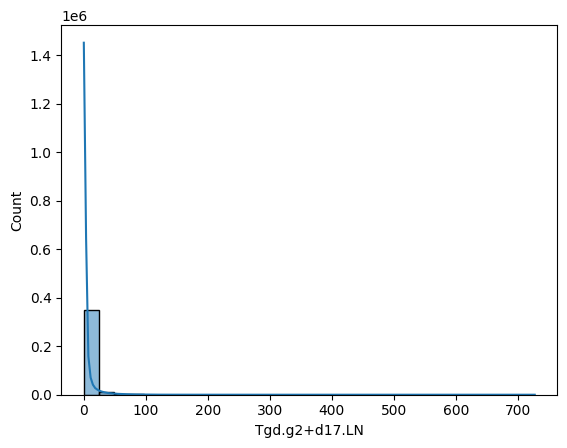

In [42]:
sns.histplot(ATAC_data_removed["Tgd.g2+d17.LN"], bins=30, kde=True)

**Verteilung rechtsschief:**
<br> sehr viele Peaks/Regionen haben niedrige ATAC-Signale
<br>wenige Peaks/Regionen haben hohe ATAC-Signale
<br>der lange rechte Schwanz zeigt: einige, aber weige Regionen sind besonders stark zugänglich/open chromatin

## Filtering by Variation

In [44]:
exclude_cols = [
    "ImmGenATAC1219.peakID",
    "chrom",
    "Summit",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATAC_celltypes = ATAC_data_removed.drop(columns=exclude_cols).copy()
ATAC_celltypes.head()

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,preB.FrD.BM,B.FrE.BM,B1b.PC,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,2.36,0.10,0.90,0.11,0.47,0.10,0.50,1.17,0.32,0.14,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,0.41,0.10,0.11,0.11,0.79,0.40,0.50,2.23,0.80,0.14,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,0.41,0.10,0.11,0.11,0.47,0.34,1.78,1.17,0.32,0.60,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
5,2.36,1.64,1.85,1.58,1.12,0.34,0.42,0.13,0.80,0.60,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
6,0.41,0.10,0.11,0.11,0.11,1.34,0.90,1.69,0.80,0.60,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02


<Axes: ylabel='Count'>

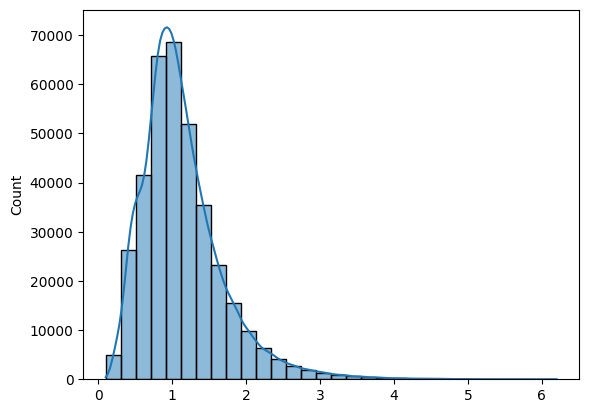

In [48]:
OCR_var_coef = ATAC_celltypes.std(axis=1) / ATAC_celltypes.mean(axis=1)
sns.histplot(OCR_var_coef, bins=30, kde=True)

In [46]:
OCR_var_coef.describe()

count    362330.000000
mean          1.138197
std           0.554413
min           0.103492
25%           0.775821
50%           1.038506
75%           1.387520
max           6.200528
dtype: float64

/var/folders/cc/3r9cpp9s7c9_s16wz91nlkn40000gn/T/ipykernel_19855/485437808.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(np.log2(ATAC_celltypes.mean(axis=1)), OCR_var_coef, s=5, cmap='viridis', alpha=0.5)


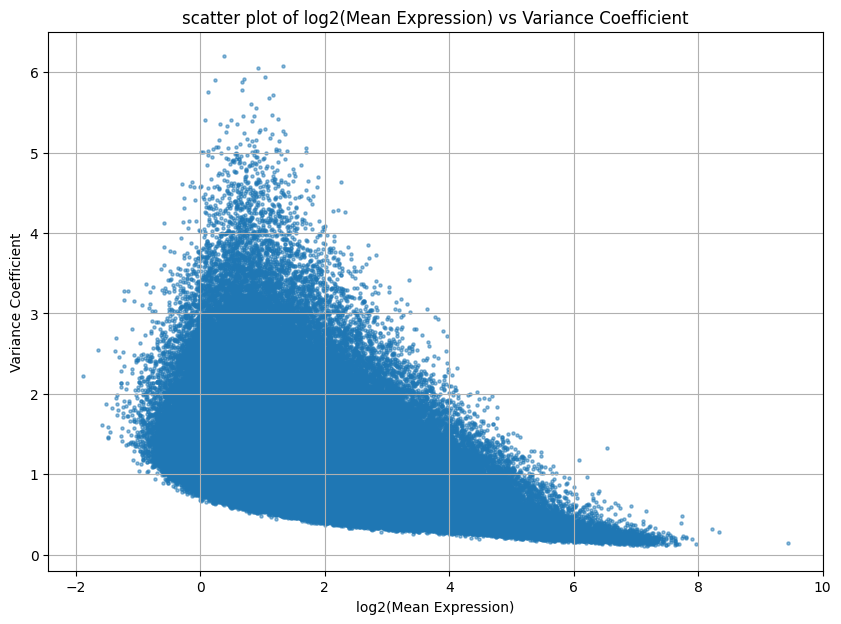

In [47]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(ATAC_celltypes.mean(axis=1)), OCR_var_coef, s=5, cmap='viridis', alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

## 1.2 Signal Variability Across CREs
<h2> Should any peaks be filtered out due to insufficient signal?

## QC Datensatz analysieren

In [43]:
mmc1_path = Path('data') / 'mmc1.xlsx'
mmc1_data = pd.read_excel(mmc1_path)
mmc1_data.head() #head: zeigt nur erste 5 Zeilen --> trotzdem alles geladen


,SampleName,CellType,ImmGenLab,Lineage,CellFamily,Organ,SortingMarkers,InputCellNumber,PF.reads,%chrM.mapped,Paired.read.after.removing.PCR.duplication,%fragment.1Kb_TSS,Replicate.cor
0,LTHSC.34-.BM#1,LTHSC.34-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34-,677,22287984,4.58,2470102,10.60,NaN
1,LTHSC.34+.BM#1,LTHSC.34+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34+,2483,28588536,3.17,7675501,7.70,NaN
2,STHSC.150-.BM#1,STHSC.150-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150-CD48-,3660,22170346,3.25,6060045,11.13,NaN
3,MPP4.135+.BM#1,MPP4.135+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135+,10000,24003590,13.83,6128252,18.96,NaN
4,proB.CLP.BM#1,proB.CLP.BM,Hardy,B,B Cell,Bone Marrow,CD19-IgM-CD43+CD24-CD45R-CD93+CD117+IL7Ra+PI-D...,10000,23578208,7.67,6588564,13.21,0.868


In [14]:
mmc1_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   SampleName                                  181 non-null    str    
 1   CellType                                    181 non-null    str    
 2   ImmGenLab                                   181 non-null    str    
 3   Lineage                                     181 non-null    str    
 4   CellFamily                                  181 non-null    str    
 5   Organ                                       181 non-null    str    
 6   SortingMarkers                              181 non-null    str    
 7   InputCellNumber                             181 non-null    int64  
 8   PF.reads                                    181 non-null    int64  
 9   %chrM.mapped                                181 non-null    float64
 10  Paired.read.after.removin

181 cell samples --> und ATAC sind um die 90. Um QC zu analysieren die rausgenommen QC metrics enternen

alle rows bei QC droppen, deren namen nicht in ATAC_data_removed beinhaltet sind

In [45]:
mmc1_removed = mmc1_data[mmc1_data["CellType"].isin(ATAC_data_removed.columns)].copy()
mmc1_removed.info()

<class 'pandas.DataFrame'>
Index: 179 entries, 0 to 180
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   SampleName                                  179 non-null    str    
 1   CellType                                    179 non-null    str    
 2   ImmGenLab                                   179 non-null    str    
 3   Lineage                                     179 non-null    str    
 4   CellFamily                                  179 non-null    str    
 5   Organ                                       179 non-null    str    
 6   SortingMarkers                              179 non-null    str    
 7   InputCellNumber                             179 non-null    int64  
 8   PF.reads                                    179 non-null    int64  
 9   %chrM.mapped                                179 non-null    float64
 10  Paired.read.after.removing.PCR

--> es wurden 2 entfernt: stromale fibroblastic reticular cells (keine klassischen Immunzellen)

In [47]:
mmc1_notremoved = mmc1_data[~mmc1_data["CellType"].isin(ATAC_data_removed.columns)].copy()
mmc1_notremoved.head()

,SampleName,CellType,ImmGenLab,Lineage,CellFamily,Organ,SortingMarkers,InputCellNumber,PF.reads,%chrM.mapped,Paired.read.after.removing.PCR.duplication,%fragment.1Kb_TSS,Replicate.cor
171,FRC.CD140a+.Madcam-.CD35-.SLN#1,FRC.CD140a+.Madcam-.CD35-.SLN,Turley,stroma,Fibroblastic reticular cell,skin draining Lymph Node,CalceinBlue+PDPN+CD31-CD21/35-Madcam1-LiveDead...,10000,25768696,6.16,8039453,7.65,0.897
172,FRC.CD140a+.Madcam-.CD35-.SLN#2,FRC.CD140a+.Madcam-.CD35-.SLN,Turley,stroma,Fibroblastic reticular cell,skin draining Lymph Node,CalceinBlue+PDPN+CD31-CD21/35-Madcam1-LiveDead...,10000,66673554,6.87,15351027,7.40,0.897


haben manche Samples sehr weinge reads?

In [9]:
mmc1_data["PF.reads"].describe()

count    1.810000e+02
mean     2.459027e+07
std      6.575663e+06
min      1.614223e+07
25%      2.104140e+07
50%      2.319932e+07
75%      2.587249e+07
max      6.667355e+07
Name: PF.reads, dtype: float64

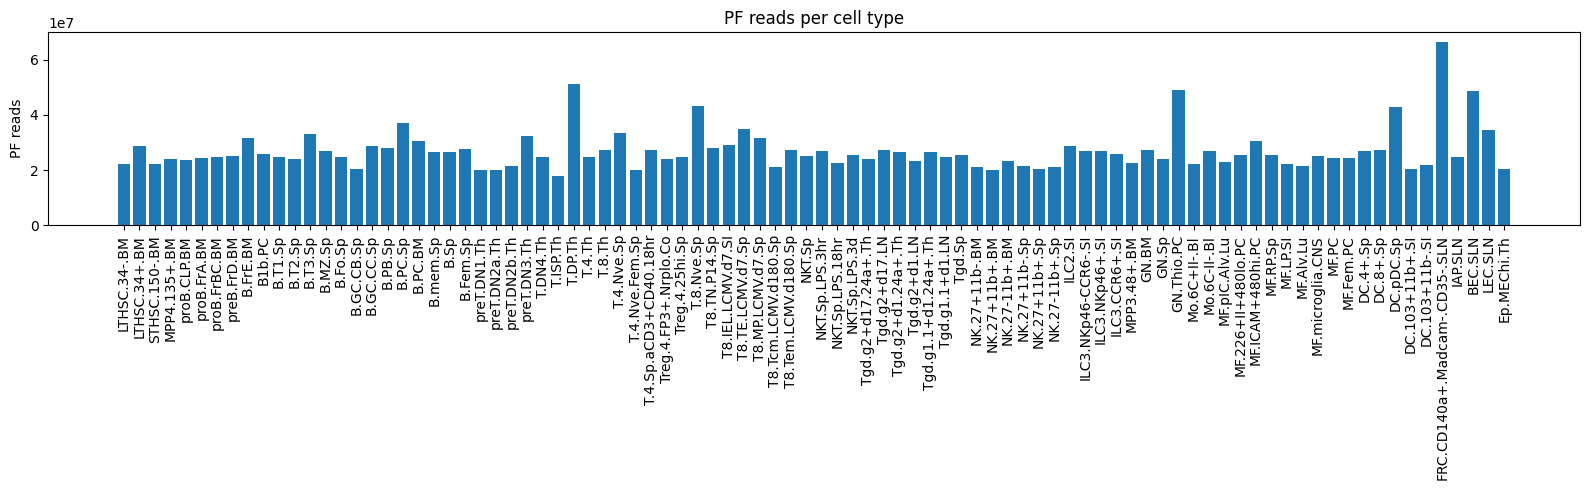

In [50]:
plt.figure(figsize=(16,5))
plt.bar(mmc1_data["CellType"], mmc1_data["PF.reads"])
plt.xticks(rotation=90)
plt.ylabel("PF reads")
plt.title("PF reads per cell type")
plt.tight_layout()
plt.show()

nach dem paper wurde ein threshold von 2,470,102. Minimum bei 16 Millionen: deutlich drüber

Wie viel ATAC-Signal hat dieser Peak insgesamt über alle verwendeten Zelltypen/Samples?

In [79]:
annotation_cols = [
    "ImmGenATAC1219.peakID",
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATAC_signal = ATAC_data_removed.drop(columns=annotation_cols)
peak_total = ATAC_signal.sum(axis=1)
peak_total.describe()

count    362330.000000
mean        458.318951
std         887.305913
min          24.420000
25%         137.700000
50%         207.290000
75%         407.510000
max       62693.390000
dtype: float64

Annotations-Spalten entfernen<br>
Gesamtsignal pro Peak berechnen (Peak 1: Signal in Sample1 + Sample2 ...; Peak 2: Signal in Sample1 + Sample2 ... )<br>

<h3>Low-Signal Peaks prüfen

In [81]:
low_signal_peaks = peak_total == 0

print("Total CREs:", ATAC_signal.shape[0])
print("Zero-signal CREs:", low_signal_peaks.sum())
print("Percent zero-signal CREs:", low_signal_peaks.mean() * 100)

Total CREs: 362330
Zero-signal CREs: 0
Percent zero-signal CREs: 0.0


In [ ]:
nonzero_peak = (ATAC_signal > 0).sum(axis=1) # > Vergleichsoperator --> gibt boolean zurück
nonzero_peak.describe()

count    362330.0
mean         90.0
std           0.0
min          90.0
25%          90.0
50%          90.0
75%          90.0
max          90.0
dtype: float64

kein peak hat Gesamtsignal 0, jeder Peak hat in allen 90 Samples ein Signal > 0

## Mittelwertilter
<br>Filter über niedrigen Mittelwert --> aber kann biologisch interessante sein, da sehr zelltypspezifische Peaks entfernt werden

In [ ]:
peak_mean = ATAC_signal.mean(axis=1)
peak_std = ATAC_signal.std(axis=1)

threshold_mean = peak_mean.quantile(0.05) #untersten 5% der peaks

ATAC_data_peaks =ATAC_data_removed


2         6.716484
3         1.533709
4         0.816587
5         1.218798
6         1.262417
            ...   
512588    3.648828
512589    4.053177
512590    4.887909
512591    4.386282
512594    1.481127
Length: 362330, dtype: float64